# Forces, relaxation, effective mass, density, and the `run_tasks()` escape hatch

Continues from `01_getting_started.ipynb`. This notebook covers the rest of the
roadmap Tier 1-3 "usability primitives" / standard-DFT-workflow surface:
`get_forces()`, `get_relaxed()`, `get_effective_mass()`, `get_density()`, and
`run_tasks()` -- the escape hatch for any Elk task not wrapped as a named method
(`docs/design.md` #3).

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from elkpy.structure import Structure

SI_AVEC = [(5.13, 5.13, 0.00), (5.13, 0.00, 5.13), (0.00, 5.13, 5.13)]
SI_SPECIES = {"Si": [(0.0, 0.0, 0.0), (0.25, 0.25, 0.25)]}

structure = Structure(SI_AVEC, SI_SPECIES)
# same workdir/parameters as 01_getting_started.ipynb -- get_calculation() re-caches
# rather than re-running the ground state, as long as the basis-defining parameters
# (xc, ngridk, vkloff, ...) still match exactly (see Calculation.ensure_ground_state())
calc = structure.get_calculation(
    "_scratch/si", xc="PW", ngridk=(2, 2, 2), vkloff=(0.25, 0.5, 0.625)
)
calc.get_energy()  # warm the cached ground state

-578.10398783797

## `get_forces()`

Total force on each atom (Hartree/Bohr), one row per atom in declaration order. The
input positions here are already the DFT-PBE/PW equilibrium geometry, so we expect
forces close to zero.

In [2]:
forces = calc.get_forces()
print("forces (Hartree/Bohr):")
print(forces)
print("max |force|:", np.abs(forces).max())

forces (Hartree/Bohr):
[[-0.  0. -0.]
 [ 0. -0.  0.]]
max |force|: 0.0


## `get_relaxed()`

Relax atomic positions (Elk task 3, `latvopt` via `extra_blocks=` for cell
relaxation too). Returns a *new* `Calculation` built from the relaxed `Structure`,
which reconverges its own ground state from atomic densities (not a resumed density)
-- see the method's docstring for why that's deliberate. Since Si is already at
equilibrium, the relaxed energy should barely move.

In [3]:
relaxed = calc.get_relaxed(workdir="_scratch/si_relaxed")
e_original = calc.get_energy()
e_relaxed = relaxed.get_energy()
print(f"original energy: {e_original:.8f} Hartree")
print(f"relaxed energy:  {e_relaxed:.8f} Hartree")
print(f"|delta|:         {abs(e_relaxed - e_original):.2e} Hartree")

original energy: -578.10398784 Hartree
relaxed energy:  -578.10398790 Hartree
|delta|:         5.95e-08 Hartree


## `get_effective_mass()`

Effective mass tensor at a given k-point (Elk task 25). At Gamma, cubic symmetry
means the tensor should be isotropic (equal diagonal elements, i.e. a scalar
effective mass).

In [4]:
states = calc.get_effective_mass((0.0, 0.0, 0.0))
first = states[0]
print("state:", first["state"], " eigenvalue:", first["eigenvalue"])
print("effective mass tensor (Cartesian):")
print(first["tensor"])
diag = first["tensor"].diagonal()
print("diagonal spread:", diag.max() - diag.min())

state: 1  eigenvalue: -0.2457029764
effective mass tensor (Cartesian):
[[ 1.16434343e+00 -1.11948901e-08 -1.11936258e-08]
 [-1.11948901e-08  1.16434343e+00 -1.11950106e-08]
 [-1.11936258e-08 -1.11950106e-08  1.16434343e+00]]
diagonal spread: 0.0


## `get_density()`

3D charge density on a grid (Elk task 33). Returns Cartesian points plus density
values; below we take a coarse grid and plot a mid-height slice through the cell to
see the density peaking around the Si-Si bond.

points shape: (13824, 3)  density shape: (13824,)
density range: 0.003796872795 2076.239173


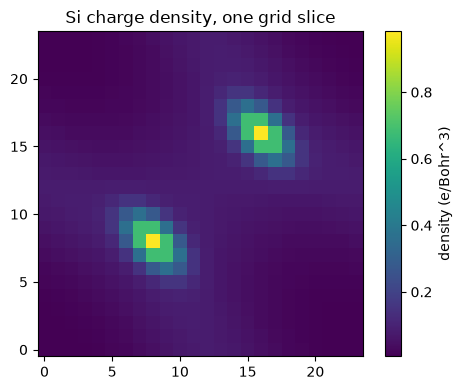

In [5]:
points, density = calc.get_density(grid=(24, 24, 24))
print("points shape:", points.shape, " density shape:", density.shape)
print("density range:", density.min(), density.max())

# a slice near z = 0 (the plot3d box spans the unit cell in lattice coordinates,
# so "mid-height" here is w.r.t. the parallelepiped's own 3rd edge, not a global z)
grid = density.reshape(24, 24, 24)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(grid[:, :, 12].T, origin="lower", cmap="viridis")
ax.set_title("Si charge density, one grid slice")
fig.colorbar(im, ax=ax, label="density (e/Bohr^3)")
fig.tight_layout()

## `run_tasks()`: the escape hatch

Not every Elk task has a named `get_*()` wrapper. `run_tasks()` runs arbitrary task
numbers (resumed from the cached ground state, same isolated-subdirectory pattern as
every other `get_*()`), and hands back the run directory for the caller to parse
whatever output file(s) that task produced. Below: task 15 ("output L, S and J total
expectation values", `docs/elk_manual.txt`), which needs a `kstlist` block (Elk
manual sec. 5.65) picking which (k-point, state) pairs to evaluate.

In [6]:
subdir = calc.run_tasks([15], blocks={"kstlist": [[1, 1]]})
print("output files:", sorted(p.name for p in subdir.iterdir()))
print()
print((subdir / "LSJ.OUT").read_text())

output files: ['DTOTENERGY.OUT', 'EFERMI.OUT', 'EIGVAL.OUT', 'EQATOMS.OUT', 'EVALCORE.OUT', 'EVALFV.OUT', 'EVALSV.OUT', 'EVECFV.OUT', 'EVECSV.OUT', 'FERMIDOS.OUT', 'GAP.OUT', 'GEOMETRY.OUT', 'IADIST.OUT', 'INFO.OUT', 'KPOINTS.OUT', 'LATTICE.OUT', 'LINENGY.OUT', 'LSJ.OUT', 'OCCSV.OUT', 'RMSDVS.OUT', 'STATE.OUT', 'SYMCRYS.OUT', 'SYMLAT.OUT', 'SYMSITE.OUT', 'TOTENERGY.OUT', 'elk.in', 'elk.out']


Expectation values are computed only over the muffin-tin

Species : 1 (Si)
 atom : 1
  L :  -0.7706640093E-18 -0.4519005001E-18 -0.2439454888E-18
  S :    0.000000000       0.000000000       0.000000000    
  J :  -0.7706640093E-18 -0.4519005001E-18 -0.2439454888E-18
 atom : 2
  L :  -0.7706640093E-18 -0.4519005001E-18 -0.2676624113E-18
  S :    0.000000000       0.000000000       0.000000000    
  J :  -0.7706640093E-18 -0.4519005001E-18 -0.2676624113E-18



## Next

- `03_phonon_dispersion_and_dos.ipynb` -- DFPT phonons (slow; not executed here).
- `04_per_species_soc_scaling.ipynb`, `05_berry_curvature.ipynb`,
  `06_eigenstate_session.ipynb` -- elkpy's own Fortran extensions.